# Broadway Data Analysis Notebook - Metric Analysis, Trends, Models, and Visualizations
By Cooper Orio

Done locally first before implementing with any major ties to a cloud service or website.

In [1]:
# Debugging: Check current working directory and file existence
import os
from pathlib import Path

# Print current working directory
print("Current working directory:", Path.cwd())

# Check if the .env file exists at the expected path
env_path = Path('..') / '.env'
print("Expected .env path:", env_path.resolve())
print(".env file exists:", env_path.exists())

# If it doesn't exist, let's search for it
if not env_path.exists():
    print("Searching for .env files in parent directory...")
    parent_dir = Path('..')
    env_files = list(parent_dir.rglob('.env'))
    print("Found .env files:", env_files)

# Let's also check what's actually in the environment
print("\nCurrent environment variables containing 'AWS':")
for key, value in os.environ.items():
    if 'AWS' in key:
        print(f"{key}: {value}")

Current working directory: C:\Users\coope\OneDrive\Desktop\broadway_ml\analysis
Expected .env path: C:\Users\coope\OneDrive\Desktop\broadway_ml\.env
.env file exists: True

Current environment variables containing 'AWS':


In [2]:
# imports & environment loading
try:
    import os
    import boto3
    import pandas as pd
    from io import StringIO
    from dotenv import load_dotenv
    from pathlib import Path
    import matplotlib.pyplot as plt
    import streamlit as st
    import plotly.express as px
    import seaborn as sns
    from data_loader import load_s3_data # may have to change later, since it is in the same file location
    print("All imports successful")
except ImportError as e:
    print(f"Missing library: {e}")

# Load .env from parent directory
env_path = Path('..') / '.env'
print(env_path)
load_dotenv(dotenv_path=env_path)

# Verify environment variables are loaded
print("AWS Access Key ID available:", os.getenv('AWS_ACCESS_KEY_ID') is not None)
print("AWS Secret Access Key available:", os.getenv('AWS_SECRET_ACCESS_KEY') is not None)

All imports successful
..\.env
AWS Access Key ID available: True
AWS Secret Access Key available: True


In [3]:
# Cell 2: Initialize S3 client
try:
    session = boto3.Session(
        aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
        aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY'),
        region_name=os.getenv('AWS_DEFAULT_REGION', 'us-east-1')
    )
    s3 = session.client('s3')
    print("S3 client initialized successfully")
except Exception as e:
    print(f"Error initializing S3 client: {e}")

S3 client initialized successfully


In [4]:
# Make sure I have access to the right bucket before pulling my data.
try:
    # List buckets to test connection
    response = s3.list_buckets()
    print("Connected to AWS S3 successfully")
    print("Available buckets:", [b['Name'] for b in response['Buckets']])
except Exception as e:
    print(f"Connection failed: {e}")

Connected to AWS S3 successfully
Available buckets: ['broadway-data-raw']


In [5]:
# Load in the data, and print an affirmation if the dataframe is actually present.
df = load_s3_data(response['Buckets'][0]['Name'], 'raw/latest/broadway_league_data.csv')
if df is not None:
    print(f"Data loaded successfully! Shape: {df.shape}")
    display(df.tail())
else:
    print("Failed to load data")

Data loaded successfully! Shape: (60042, 11)


,Week End,Show,Type,Theatre,#Prev,#Perf,Grosses ($),LW Grosses ($),Attend,LW Attend,% Cap
60037,2025-09-14,THE GREAT GATSBY,Musical,Broadway,0.0,8.0,895293.0,623585.0,10105.0,6920.0,85.0
60038,2025-09-14,THE LION KING,Musical,Minskoff,0.0,8.0,1692809.0,1451644.0,13319.0,12496.0,98.0
60039,2025-09-14,THE OUTSIDERS,Musical,Jacobs,0.0,8.0,1000244.0,750426.0,7788.0,6717.0,95.0
60040,2025-09-14,WAITING FOR GODOT 2025,Play,Hudson,1.0,0.0,367206.0,0.0,974.0,0.0,100.0
60041,2025-09-14,WICKED,Musical,Gershwin,0.0,8.0,2003313.0,2005301.0,15408.0,15408.0,100.0


In [6]:
df[df['Show'] == 'THE LION KING']['Theatre'].unique()

array(['New Amsterdam', 'Minskoff'], dtype=object)

## Additional Cursory Data Exploration
Here I do some exploration on the data itself, not making any major pointed analytical questions, building models, or generating sophisticated visualizations. I did most of my exploration when I was making my cleaning pipeline I use before the uploading the data to S3. However, this is the space I gave myself for any additional exploration that may be needed.

## Trends and Visualizations

In [7]:
def plot_by_show(bw_df, showname, metric):
    show_df = bw_df[bw_df['Show'] == showname]
    theatres = show_df['Theatre'].unique()
    show_df.loc[:, 'Week End'] = pd.to_datetime(show_df['Week End'])

    sns.relplot(data=show_df, x='Week End', y=metric, hue='Theatre', aspect=1.61)
    plt.xlabel('Week End')
    plt.show()

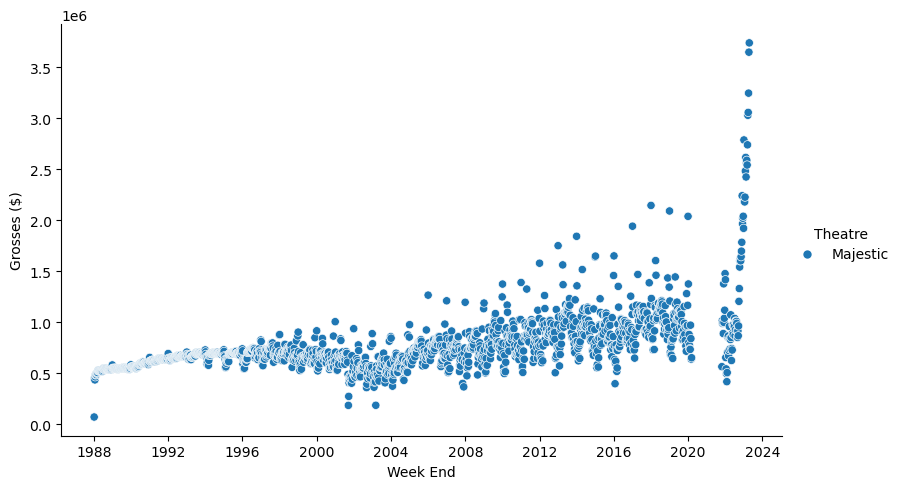

In [12]:
plot_by_show(df, showname = 'THE PHANTOM OF THE OPERA', metric = 'Grosses ($)')

In [9]:
def total_grosses_by_time(df, start_date, end_date, metric='Grosses ($)'):
    # converts stuff to datetime first
    df = df.copy()
    df['Week End'] = pd.to_datetime(df['Week End'])
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    
    # Group by week and sum the metric
    week_sum_df = df.groupby('Week End', as_index=False)[metric].sum()
    
    # Filter the DataFrame
    plot_df = week_sum_df[(week_sum_df['Week End'] >= start) & (week_sum_df['Week End'] <= end)]
    
    # Plot using lineplot instead of relplot since there's no hue needed
    sns.relplot(data=plot_df, x='Week End', y=metric)
    plt.xlabel('Week End')
    plt.ylabel(metric)
    plt.title(f'Total {metric} by Week')
    plt.show()

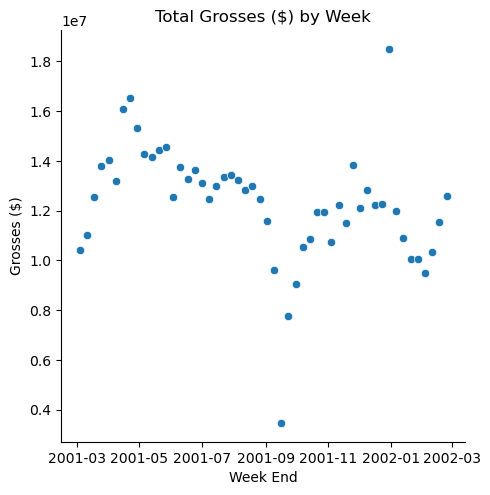

In [10]:
total_grosses_by_time(df, '2001-03-01', '2002-03-01')

## Modeling and Further Analysis